<a href="https://colab.research.google.com/github/BryanHinostroza/tarea10-bh/blob/develop/MD_tarea10_Hinostroza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA 10: ANÁLISIS DE CONGLOMERADOS


a. Halle la matriz de distancias para cada iteración.

In [1]:
# Paso 1: Importar librerías necesarias
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [2]:
# Paso 2: Crear el DataFrame con los datos
data = {
    'Observaciones': ['A', 'B', 'C', 'D', 'E', 'F'],
    'x': [1, 6, 3, 6, 2, 8],
    'y': [2, 8, 1, 5, 1, 6]
}

df = pd.DataFrame(data)
df.set_index('Observaciones', inplace=True)

In [7]:
# Paso 3: Calcular matriz de distancias euclidianas
dist_matrix = pd.DataFrame(
    squareform(pdist(df.values, metric='euclidean')),
    columns=df.index,
    index=df.index
)

print("Matriz de distancias euclidianas:")
print(dist_matrix.round(2))

Matriz de distancias euclidianas:
Observaciones     A     B     C     D     E     F
Observaciones                                    
A              0.00  7.81  2.24  5.83  1.41  8.06
B              7.81  0.00  7.62  3.00  8.06  2.83
C              2.24  7.62  0.00  5.00  1.00  7.07
D              5.83  3.00  5.00  0.00  5.66  2.24
E              1.41  8.06  1.00  5.66  0.00  7.81
F              8.06  2.83  7.07  2.24  7.81  0.00


In [5]:
# Paso 4: Clustering jerárquico (aglomerativo)
Z = linkage(df.values, method='single', metric='euclidean')

# Mostrar la matriz de enlaces (cada fila es una iteración)
print("\n Matriz de enlaces (linkage matrix):")
linkage_df = pd.DataFrame(Z, columns=["Cluster 1", "Cluster 2", "Distancia", "Elementos en clúster"])
print(linkage_df)


 Matriz de enlaces (linkage matrix):
   Cluster 1  Cluster 2  Distancia  Elementos en clúster
0        2.0        4.0   1.000000                   2.0
1        0.0        6.0   1.414214                   3.0
2        3.0        5.0   2.236068                   2.0
3        1.0        8.0   2.828427                   3.0
4        7.0        9.0   5.000000                   6.0


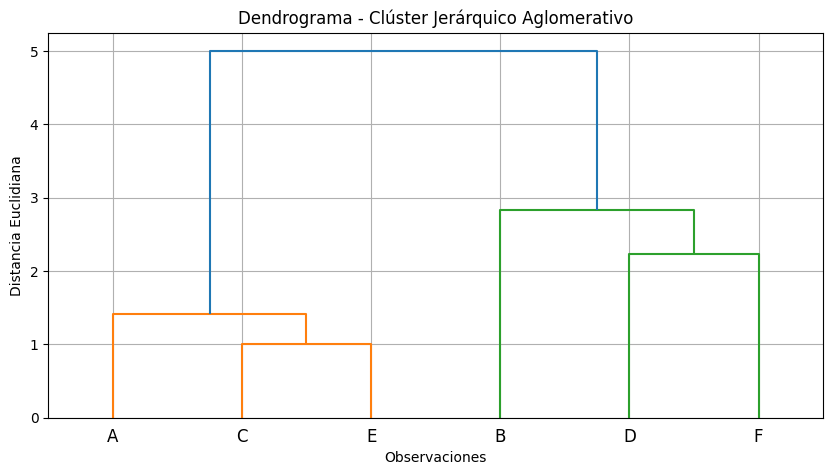

In [8]:
# Paso 5: Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=df.index.tolist())
plt.title('Dendrograma - Clúster Jerárquico Aglomerativo')
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')
plt.grid(True)
plt.show()

b. Halle los centroides de los nuevos clústers y actualizar la matriz de datos para cada iteración.

In [9]:
# Rehacer el linkage usando método 'centroid' para este ejercicio
Z_centroid = linkage(df.values, method='centroid')

In [12]:
# Inicializar estructuras
clusters = {i: [i] for i in range(len(df))}
points = df.values.tolist()

def calcular_centroide(indices):
    coords = np.array([points[i] for i in indices])
    return np.mean(coords, axis=0)

print("INICIO - Clustering con método 'centroid':\n")

for step, (idx1, idx2, dist, n_points) in enumerate(Z_centroid):
    idx1, idx2 = int(idx1), int(idx2)
    nuevo_idx = len(points)

    nuevo_cluster = clusters[idx1] + clusters[idx2]
    nuevo_centroide = calcular_centroide(nuevo_cluster)
    points.append(nuevo_centroide)

    clusters[nuevo_idx] = nuevo_cluster
    del clusters[idx1]
    del clusters[idx2]

    print(f"Iteración {step+1}")
    print(f"Se fusionan clúster {idx1} y {idx2} → Nuevo clúster {nuevo_idx}")
    print(f"Centroide: {nuevo_centroide.round(2)}")

    matriz_actual = pd.DataFrame([points[i] for i in sorted(clusters.keys())],
                                 index=[f"C{i}" for i in sorted(clusters.keys())],
                                 columns=["x", "y"])
    print("Matriz actualizada:")
    print(matriz_actual.round(2))
    print("-" * 40)

INICIO - Clustering con método 'centroid':

Iteración 1
Se fusionan clúster 2 y 4 → Nuevo clúster 6
Centroide: [2.5 1. ]
Matriz actualizada:
      x    y
C0  1.0  2.0
C1  6.0  8.0
C3  6.0  5.0
C5  8.0  6.0
C6  2.5  1.0
----------------------------------------
Iteración 2
Se fusionan clúster 0 y 6 → Nuevo clúster 7
Centroide: [2.   1.33]
Matriz actualizada:
      x     y
C1  6.0  8.00
C3  6.0  5.00
C5  8.0  6.00
C7  2.0  1.33
----------------------------------------
Iteración 3
Se fusionan clúster 3 y 5 → Nuevo clúster 8
Centroide: [7.  5.5]
Matriz actualizada:
      x     y
C1  6.0  8.00
C7  2.0  1.33
C8  7.0  5.50
----------------------------------------
Iteración 4
Se fusionan clúster 1 y 8 → Nuevo clúster 9
Centroide: [6.67 6.33]
Matriz actualizada:
       x     y
C7  2.00  1.33
C9  6.67  6.33
----------------------------------------
Iteración 5
Se fusionan clúster 7 y 9 → Nuevo clúster 10
Centroide: [4.33 3.83]
Matriz actualizada:
        x     y
C10  4.33  3.83
-------------------

c. Repita el proceso hasta que solamente queden dos clústers.

In [16]:
# Reiniciamos clusters y points para evitar errores si se corre después de Ejercicio 2
clusters = {i: [i] for i in range(len(df))}
points = df.values.tolist()

print("INICIO - Proceso hasta dejar solo 2 clústers:\n")

for step, (idx1, idx2, dist, n_points) in enumerate(Z_centroid):
    idx1, idx2 = int(idx1), int(idx2)
    nuevo_idx = len(points)

    nuevo_cluster = clusters[idx1] + clusters[idx2]
    nuevo_centroide = calcular_centroide(nuevo_cluster)
    points.append(nuevo_centroide)

    clusters[nuevo_idx] = nuevo_cluster
    del clusters[idx1]
    del clusters[idx2]

    print(f"Iteración {step+1}")
    print(f"Se fusionan clúster {idx1} y {idx2} → Nuevo clúster {nuevo_idx}")
    print(f"Centroide: {nuevo_centroide.round(2)}")

    matriz_actual = pd.DataFrame([points[i] for i in sorted(clusters.keys())],
                                 index=[f"C{i}" for i in sorted(clusters.keys())],
                                 columns=["x", "y"])
    print("Matriz actualizada:")
    print(matriz_actual.round(2))
    print("-" * 40)

    if len(clusters) == 2:
        print("Proceso detenido: solo quedan 2 clústers.")
        break

INICIO - Proceso hasta dejar solo 2 clústers:

Iteración 1
Se fusionan clúster 2 y 4 → Nuevo clúster 6
Centroide: [2.5 1. ]
Matriz actualizada:
      x    y
C0  1.0  2.0
C1  6.0  8.0
C3  6.0  5.0
C5  8.0  6.0
C6  2.5  1.0
----------------------------------------
Iteración 2
Se fusionan clúster 0 y 6 → Nuevo clúster 7
Centroide: [2.   1.33]
Matriz actualizada:
      x     y
C1  6.0  8.00
C3  6.0  5.00
C5  8.0  6.00
C7  2.0  1.33
----------------------------------------
Iteración 3
Se fusionan clúster 3 y 5 → Nuevo clúster 8
Centroide: [7.  5.5]
Matriz actualizada:
      x     y
C1  6.0  8.00
C7  2.0  1.33
C8  7.0  5.50
----------------------------------------
Iteración 4
Se fusionan clúster 1 y 8 → Nuevo clúster 9
Centroide: [6.67 6.33]
Matriz actualizada:
       x     y
C7  2.00  1.33
C9  6.67  6.33
----------------------------------------
Proceso detenido: solo quedan 2 clústers.


Grafico para centroides y observaciones por iteración

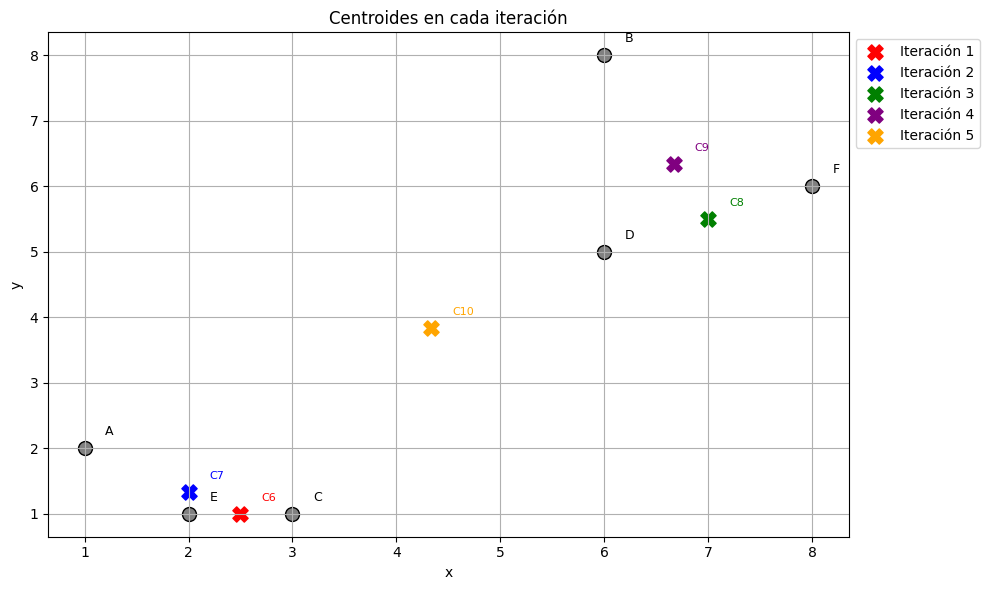

In [23]:
# Reiniciar estructuras para graficar el proceso completo
clusters = {i: [i] for i in range(len(df))}
points = df.values.tolist()
colores = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'black', 'brown']

plt.figure(figsize=(10, 6))
plt.title("Centroides en cada iteración")
plt.xlabel("x")
plt.ylabel("y")

# Graficar puntos originales
for i, (x, y) in enumerate(df.values):
    plt.scatter(x, y, c='gray', s=100, edgecolors='k')
    plt.text(x+0.2, y+0.2, df.index[i], fontsize=9, color='black')

# Ahora graficar centroides iterativamente
for step, (idx1, idx2, dist, n_points) in enumerate(Z_centroid):
    idx1, idx2 = int(idx1), int(idx2)
    nuevo_idx = len(points)

    nuevo_cluster = clusters[idx1] + clusters[idx2]
    nuevo_centroide = calcular_centroide(nuevo_cluster)
    points.append(nuevo_centroide)

    clusters[nuevo_idx] = nuevo_cluster
    del clusters[idx1]
    del clusters[idx2]

    cx, cy = nuevo_centroide
    plt.scatter(cx, cy, c=colores[step % len(colores)], s=120, marker='X', label=f"Iteración {step+1}")
    plt.text(cx+0.2, cy+0.2, f"C{nuevo_idx}", fontsize=8, color=colores[step % len(colores)])

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()